[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/10_multiple_testing.ipynb)

# Multiple Testing  
  
In A/B experiments we rarely test a single hypothesis. A typical experiment tracks several metrics simultaneously — revenue, conversion rate, average order value, CTR — and the analyst wants *at least one* of them to fire when a real effect exists.

This creates the **multiple testing problem**: even when no metric is affected, the probability of at least one false positive grows rapidly with the number of tests.

For $m$ independent tests each at level $\alpha$, the **Family-Wise Error Rate (FWER)** without any correction is:

$$\text{FWER} = 1 - (1 - \alpha)^m$$

| Tests ($m$) | FWER (α = 0.05) |
|:-----------:|:---------------:|
| 1           | 5 %             |
| 3           | 14 %            |
| 5           | 23 %            |
| 10          | 40 %            |
| 20          | 64 %            |

In practice the tests are correlated (same users, same period), so the actual inflation differs from the formula — which is exactly why we benchmark empirically rather than rely on closed-form bounds.

Two families of corrections address the problem:

* **FWER-controlling** methods (Bonferroni, Holm–Bonferroni, Šidák, …) guarantee that the probability of *any* false positive stays below α. Strict but conservative.
* **FDR-controlling** methods (Benjamini–Hochberg, Benjamini–Yekutieli, …) bound the *expected fraction* of false positives among all rejections. More power at the cost of weaker per-comparison guarantees.

`BenchMarker` ships two methods that quantify both sides of the trade-off via Monte Carlo:

* `multi_test_1_type_error` — measures empirical FWER for each correction method
* `multi_test_power` — measures power (AvgP / APP / AllP) for each correction method


In [1]:
import numpy as np
from scipy import stats

from mcab.core import (
    AaDataIid, AaDataRatio,
    DesignerIid, DesignerRatioLin,
    BenchMarker, RandomData,
)

# ── Reproducible synthetic data ────────────────────────────────────────────
rd = RandomData(seed=42)

# 1. ARPU  — continuous, iid
arpu_data = rd.normal_data(size=10_000, mean=500, std=150)

# 2. Conversion — binary, iid
conv_data = rd.proportion_data(size=10_000, p=0.08)

# 3. Avg bill — ratio metric (revenue / purchases), linearised
avg_bill_num, avg_bill_denom = rd.ratio_data_avg_bill(size=10_000)

# 4. CTR — ratio metric (clicks / impressions), linearised
ctr_num, ctr_denom = rd.ratio_data_ctr(size=10_000, ctr=0.05)

# ── Designers ──────────────────────────────────────────────────────────────
pval_ttest = lambda t, c: stats.ttest_ind(t, c).pvalue

designer_arpu = DesignerIid(
    AaDataIid(arpu_data, proportion=False),
    name='ARPU',
    pval_func=pval_ttest,
)

designer_conv = DesignerIid(
    AaDataIid(conv_data, proportion=True),
    name='Conversion',
    pval_func=pval_ttest,
)

designer_avg_bill = DesignerRatioLin(
    AaDataRatio((avg_bill_num, avg_bill_denom)),
    name='Avg Bill',
    pval_func=pval_ttest,
)

designer_ctr = DesignerRatioLin(
    AaDataRatio((ctr_num, ctr_denom), proportion=True),
    name='CTR',
    pval_func=pval_ttest,
)

designers = [designer_arpu, designer_conv, designer_avg_bill, designer_ctr]

# ── BenchMarker ────────────────────────────────────────────────────────────
bm = BenchMarker(designers, alpha=0.05, beta=0.20, seed=42)

print(f'Metrics in the family: {bm.labels}')
print(f'Theoretical FWER (no correction, independent): '
      f'{1 - (1 - 0.05) ** len(designers):.1%}')

Metrics in the family: ['ARPU', 'Conversion', 'Avg Bill', 'CTR']
Theoretical FWER (no correction, independent): 18.5%


## Naive Baseline: No Correction

Let's first confirm that running four simultaneous tests without any correction inflates the FWER above the nominal α = 0.05.

We run `multi_test_1_type_error` with `multi_corrections='no_correction'` — a single "method" that leaves every p-value untouched and simply checks whether *any* of the four tests rejects H₀ in each AA simulation.

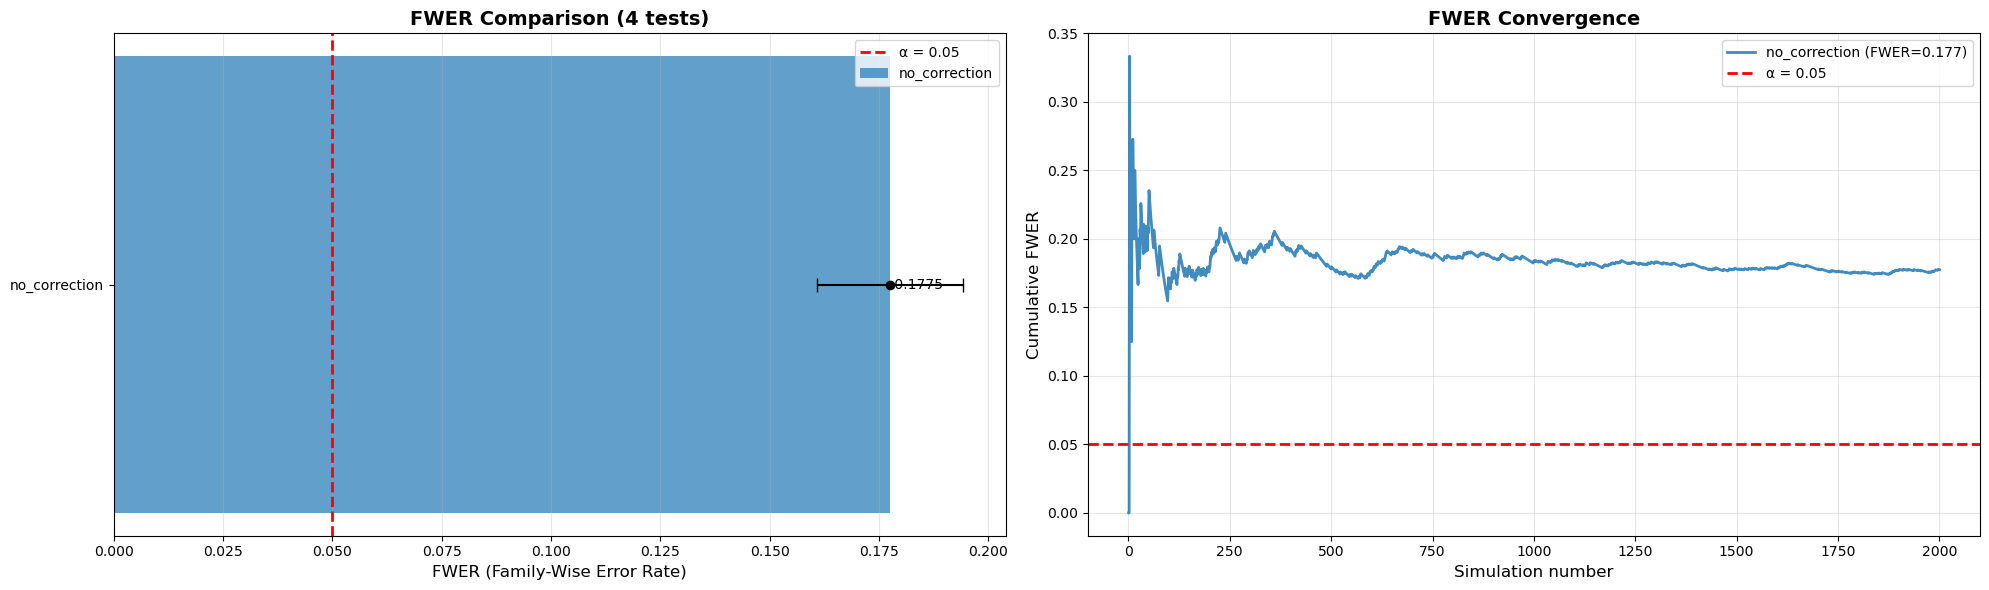


Observed FWER (no correction): 17.8%  (theoretical ≈ 18.5%)


In [2]:
results_naive = bm.multi_test_1_type_error(
    multi_corrections='no_correction',
    n_sims=2_000,
    verbose=False,
    n_jobs=-1
)

naive_fwer = results_naive['no_correction']['fwer']
print(f"\nObserved FWER (no correction): {naive_fwer:.1%}  "
      f"(theoretical ≈ {1-(1-0.05)**len(designers):.1%})")

The observed FWER is well above the nominal 5 %. Notice that the empirical value is usually *lower* than the independence-based theoretical bound because our four metrics are measured on the same users, introducing positive correlation between tests — correlated errors partially cancel each other out.

Either way, the uncorrected rate is unacceptable for a production experiment platform. We need a correction.

## All Built-in Corrections — Type I Error

`BenchMarker` ships nine ready-to-use correction methods.  
Pass `multi_corrections='all'` to evaluate every one of them in a single call.

| Method | Controls | Notes |
|--------|----------|-------|
| `no_correction` | — | baseline |
| `bonferroni` | FWER | divide α by *m*; most conservative |
| `holm_bonferroni` | FWER | step-down; uniformly more powerful than Bonferroni |
| `hochberg` | FWER | step-up; slightly more powerful than Holm under independence |
| `sidak` | FWER | Bonferroni-like but tighter when tests are independent |
| `holm_sidak` | FWER | step-down Šidák |
| `benjamini_hochberg` | FDR | most popular FDR method; assumes independence or PRDS |
| `benjamini_yekutieli` | FDR | valid under arbitrary dependence; more conservative |
| `benjamini_krieger_yekutieli` | FDR (adaptive) | two-stage BH; estimates true null proportion |

The visualization shows a bar chart of empirical FWER per method with 95 % confidence intervals, plus a convergence plot.

* 🟩 Green bar — FWER ≤ α (method controls the error rate)
* 🟥 Red bar — FWER > α (method fails to control the error rate)


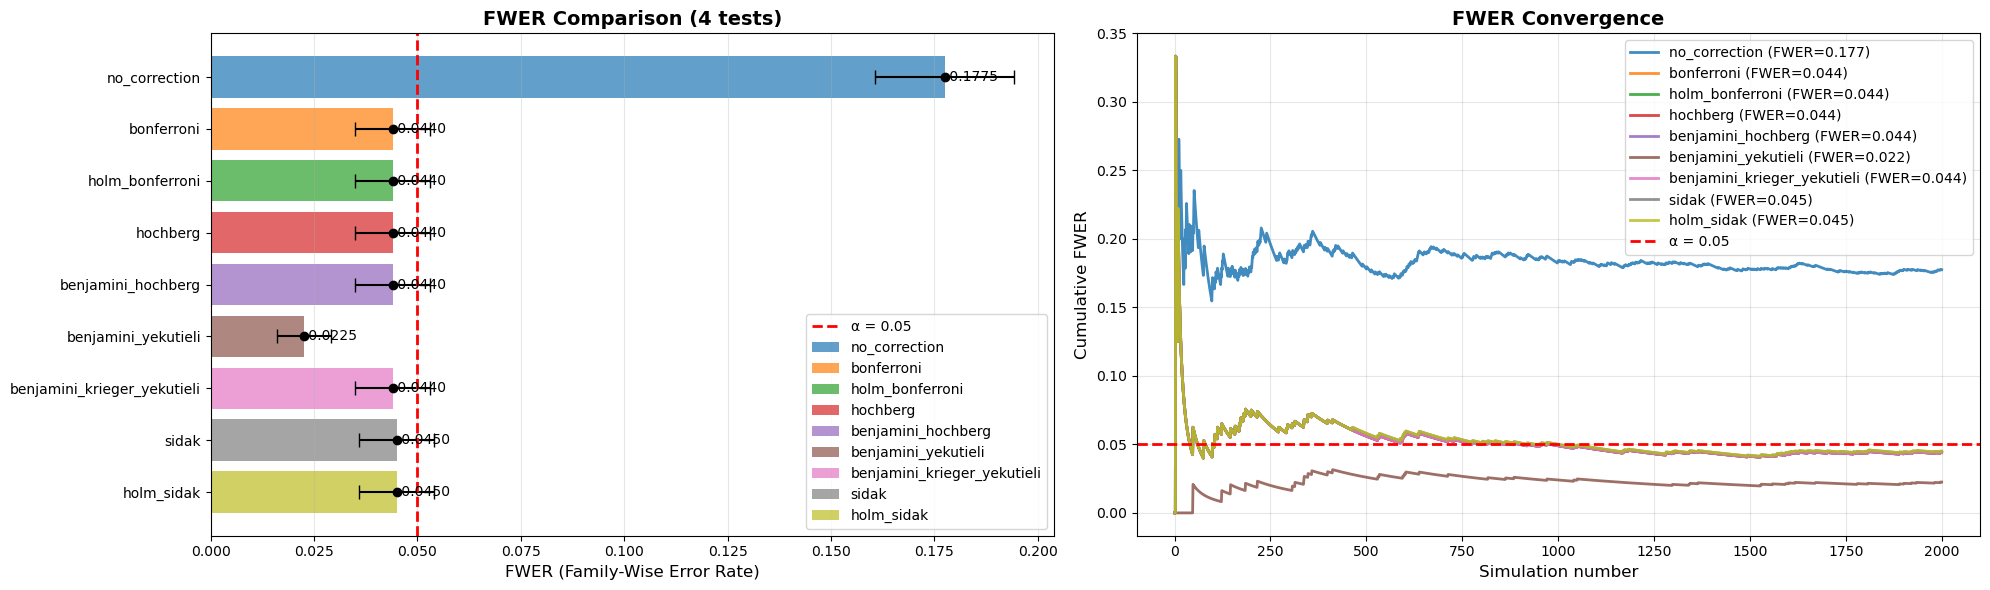


Method                                FWER            95% CI   OK?
--------------------------------------------------------------------
no_correction                       17.8%  [0.161, 0.194]     ❌
bonferroni                           4.4%  [0.035, 0.053]     ✅
holm_bonferroni                      4.4%  [0.035, 0.053]     ✅
hochberg                             4.4%  [0.035, 0.053]     ✅
benjamini_hochberg                   4.4%  [0.035, 0.053]     ✅
benjamini_yekutieli                  2.2%  [0.016, 0.029]     ✅
benjamini_krieger_yekutieli          4.4%  [0.035, 0.053]     ✅
sidak                                4.5%  [0.036, 0.054]     ✅
holm_sidak                           4.5%  [0.036, 0.054]     ✅


In [3]:
results_all = bm.multi_test_1_type_error(
    multi_corrections='all',
    n_sims=2_000,
    verbose=False,
    n_jobs=-1,
)

# Print a compact summary table
print(f"\n{'Method':<35} {'FWER':>6}  {'95% CI':>16}  {'OK?':>4}")
print('-' * 68)
for method, res in results_all.items():
    ok = '✅' if res['fwer'] <= bm.alpha else '❌'
    print(f"{method:<35} {res['fwer']:>5.1%}  "
          f"[{res['fwer_ci_left']:.3f}, {res['fwer_ci_right']:.3f}]  {ok:>4}")


## Selecting the Methods You Care About

Evaluating all nine methods at once is useful for an initial survey, but in practice you will quickly narrow down to a relevant subset — perhaps comparing the most popular FDR method against a strict FWER-controlling one.

Pass any combination as a list of strings to `multi_corrections`:

```python
multi_corrections=['no_correction', 'bonferroni', 'holm_bonferroni', 'benjamini_hochberg']
```

When to prefer which family:  
  
- FWER (Bonferroni / Holm): confirmatory experiments where a false positive has a high business cost (launching a broken feature, a regulatory submission).  
- FDR (Benjamini–Hochberg): exploratory experiments where you test many hypotheses and accept a small fraction of false positives among your discoveries (feature screening, personalisation).

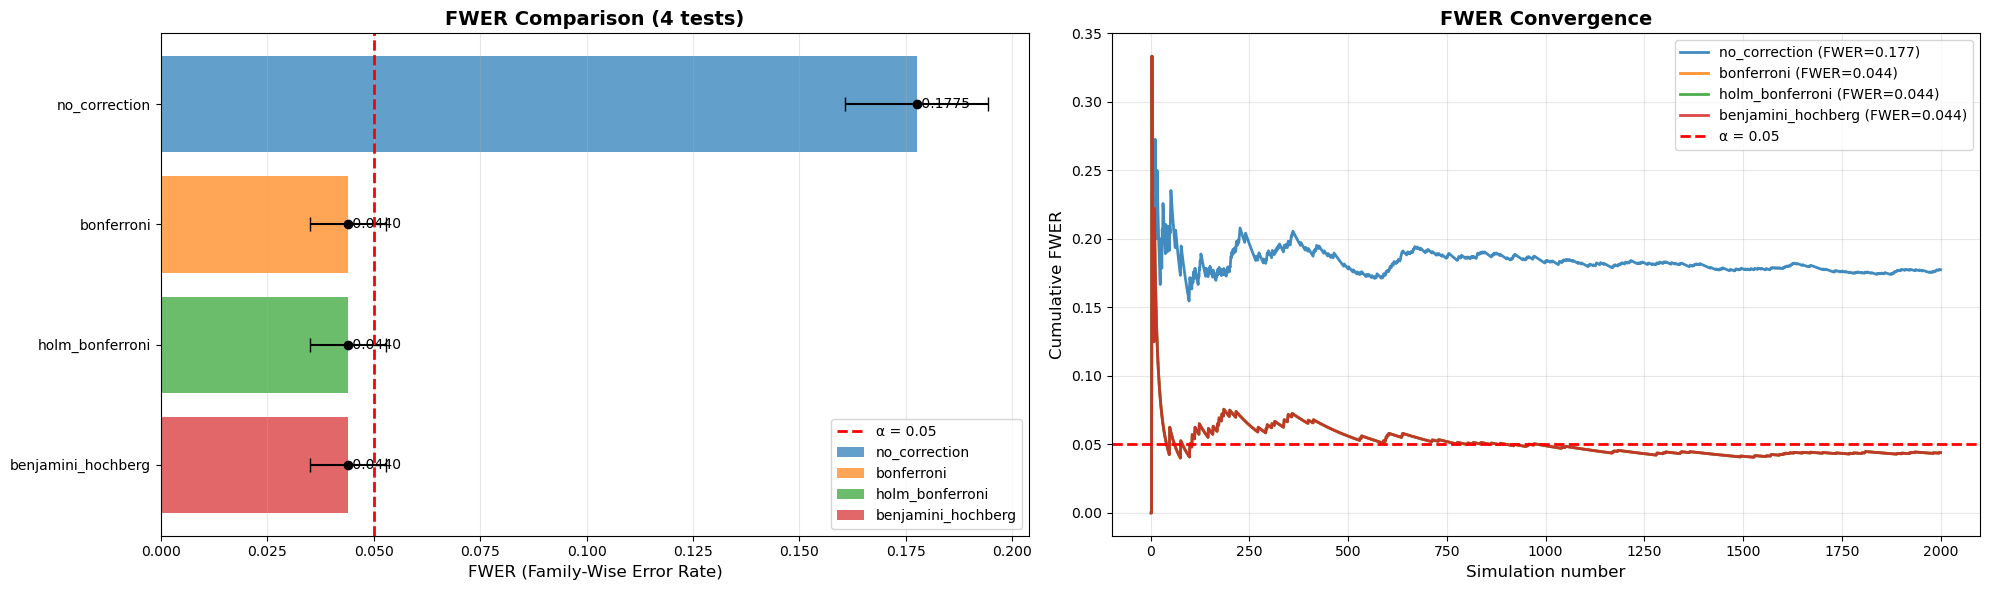

In [4]:
SELECTED_METHODS = ['no_correction', 'bonferroni', 'holm_bonferroni', 'benjamini_hochberg']

results_selected = bm.multi_test_1_type_error(
    multi_corrections=SELECTED_METHODS,
    n_sims=2_000,
    verbose=False,
    n_jobs=-1
)

## Adding a Custom Correction Method

Both `multi_test_1_type_error` and `multi_test_power` accept custom correction functions via a `(name, func)` tuple.  
The function signature is:

```python
def my_correction(pvals: np.ndarray) -> np.ndarray:
    """Takes a 1-D array of raw p-values, returns adjusted p-values."""
    ...
```
You can pass a single tuple, a list of tuples, or a mixed list that combines strings and tuples:  
  
```python
multi_corrections = [
    'bonferroni',                            # built-in string
    ('My Correction', my_correction_func),   # custom tuple
]
```
  
Below we implement a per-family Šidák correction from scratch as an example, and benchmark it alongside the built-in Bonferroni:

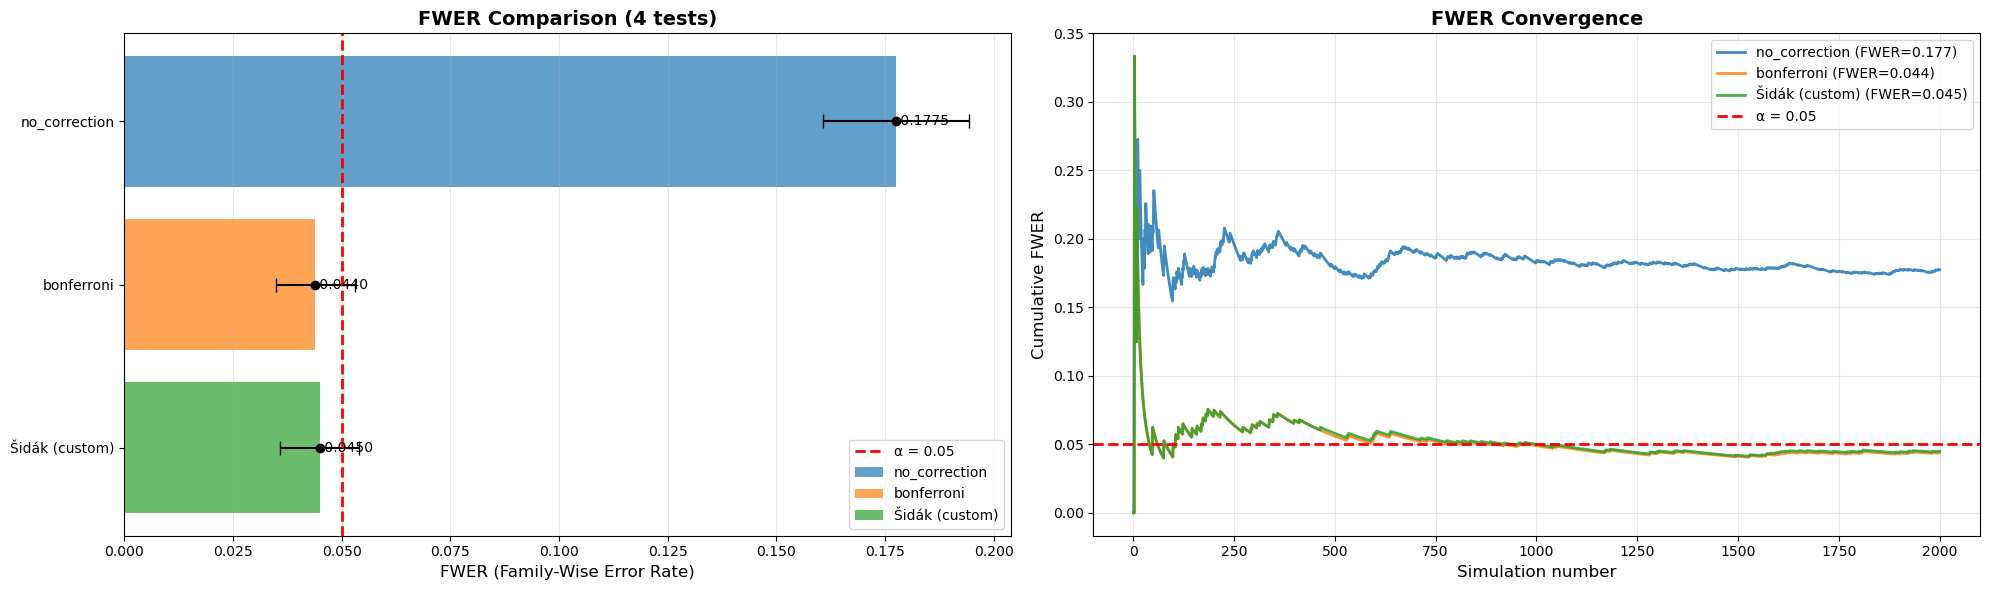


Built-in Šidák vs custom implementation:
  built-in sidak  FWER = 0.045
  custom  Šidák   FWER = 0.045


In [5]:
def sidak_custom(pvals: np.ndarray) -> np.ndarray:
    """
    Šidák correction: p_adj_i = 1 - (1 - p_i)^m
    Assumes independence between tests.
    """
    m = len(pvals)
    return 1.0 - (1.0 - pvals) ** m


custom_sidak = ('Šidák (custom)', sidak_custom)

results_custom = bm.multi_test_1_type_error(
    multi_corrections=['no_correction', 'bonferroni', custom_sidak],
    n_sims=2_000,
    verbose=False,
    n_jobs=-1,
)

print("\nBuilt-in Šidák vs custom implementation:")
print(f"  built-in sidak  FWER = {results_all['sidak']['fwer']:.3f}")
print(f"  custom  Šidák   FWER = {results_custom['Šidák (custom)']['fwer']:.3f}")

## Power Under Multiple Testing

Controlling Type I error is necessary but not sufficient — a correction that reduces power to near zero is useless.  
`multi_test_power` measures **three complementary power metrics** for the same family of tests:

| Metric | Definition | When to use |
|--------|-----------|-------------|
| **AvgP** (Average Power) | Mean fraction of true effects detected per experiment | you care about *how many* effects you catch on average |
| **APP** (Any-Pair Power) | P(≥ 1 effect detected) | you declare success if *at least one* metric fires |
| **AllP** (All-Pairs Power) | P(all effects detected) | you need *every* metric to be significant |

`bar_effect` sets the relative effect applied to **all** designers (here +5 % on each metric).  
`power_curve_effects` sweeps a range of effects to build full power curves.


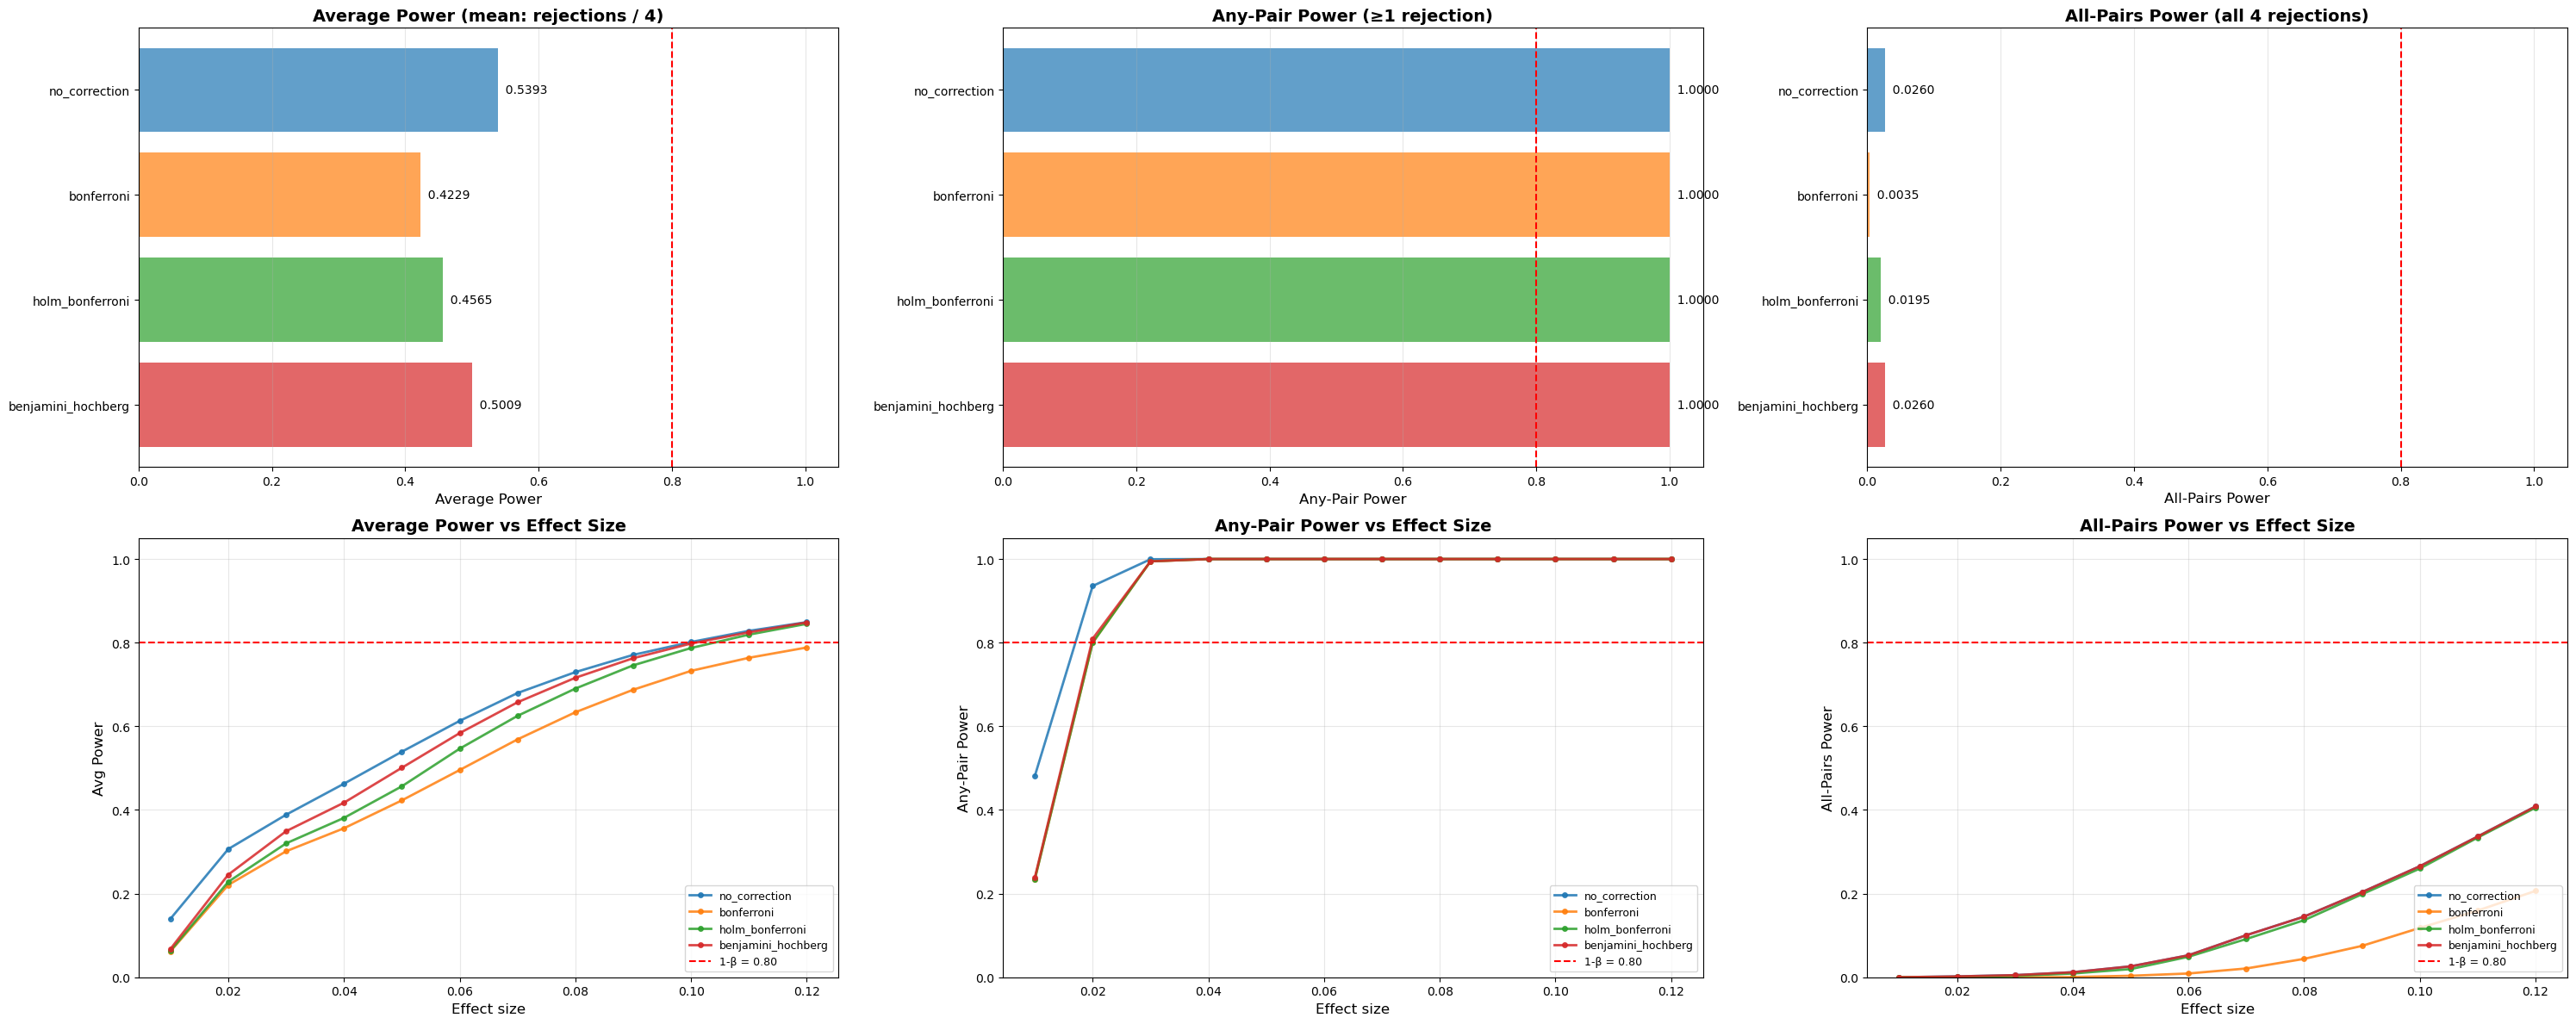

In [6]:
results_power = bm.multi_test_power(
    multi_corrections=['no_correction', 'bonferroni', 'holm_bonferroni', 'benjamini_hochberg'],
    bar_effect=0.05,
    power_curve_effects=np.linspace(0.01, 0.12, 12),
    n_sims=2_000,
    verbose=False,
    n_jobs=-1
)

## The Core Trade-off: Error Control vs Power

Stricter error control always comes at the cost of lower power. The table below makes this explicit using the results from the two benchmarks above.


In [7]:
import pandas as pd

rows = []
for method in ['no_correction', 'bonferroni', 'holm_bonferroni', 'benjamini_hochberg']:
    fwer = results_selected.get(method, {}).get('fwer', results_all.get(method, {}).get('fwer', float('nan')))
    pwr  = results_power.get(method, {})
    rows.append({
        'Method':     method,
        'FWER':       f"{fwer:.1%}",
        'FWER ≤ α?':  '✅' if fwer <= bm.alpha else '❌',
        'AvgP':       f"{pwr.get('avg_power',   float('nan')):.1%}",
        'APP':        f"{pwr.get('any_pair_power', float('nan')):.1%}",
        'AllP':       f"{pwr.get('all_pairs_power', float('nan')):.1%}",
    })

df_summary = pd.DataFrame(rows).set_index('Method')
print(df_summary.to_string())


                     FWER FWER ≤ α?   AvgP     APP  AllP
Method                                                  
no_correction       17.8%         ❌  53.9%  100.0%  2.6%
bonferroni           4.4%         ✅  42.3%  100.0%  0.4%
holm_bonferroni      4.4%         ✅  45.6%  100.0%  1.9%
benjamini_hochberg   4.4%         ✅  50.1%  100.0%  2.6%


## Summary & Checklist

### Key takeaways  

1. **Running multiple tests without correction inflates FWER.** With 4 correlated metrics it is typically in the 15–20 % range — three to four times the nominal α.
2. **Monte Carlo beats formulas.** Theoretical bounds (e.g. `1-(1-α)^m`) assume independence. Real-world metrics are correlated, so empirical simulation via `multi_test_1_type_error` gives the true number.
3. **Choose the error-rate family deliberately.** FWER (Bonferroni/Holm) for confirmatory decisions; FDR (Benjamini–Hochberg) for exploratory screening.
4. **Always check power after choosing a correction.** A method that keeps FWER ≤ α but leaves AllP < 40 % may not be worth running the experiment.
5. **Custom corrections plug straight into the same benchmark.** Pass `(name, func)` to validate any novel method before shipping it.

---

### Pre-experiment checklist

- [ ] **Define the metric family upfront.** List every metric you will test before the experiment starts — adding metrics post-hoc invalidates the correction.
- [ ] **Choose FWER or FDR control** based on the decision type (confirmatory vs exploratory).
- [ ] **Benchmark FWER empirically** via `multi_test_1_type_error` on your actual pre-experiment data to account for correlations.
- [ ] **Check all three power metrics** (`AvgP`, `APP`, `AllP`) via `multi_test_power` to ensure the chosen correction still leaves enough detection capacity.
- [ ] **Fix the correction method before the experiment** — never change it after peeking at results.
- [ ] **Re-run the benchmark whenever the metric set changes** (adding or removing a metric alters the family size and changes both FWER and power).